### Environment Setup

In [ ]:
 
# ENVIRONMENT SETUP
 
from google.colab import drive
drive.mount('/content/drive')
import subprocess


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CompletedProcess(args=['pip', 'install', 'sacremoses', '-q'], returncode=0)

In [14]:
subprocess.run(["unzip", "-uq", "/content/drive/My Drive/radioblip_ver6.zip",
                "-d", "/content"], check=True)
subprocess.run(["unzip", "-uq", "/content/drive/My Drive/stage2_best_10.zip",
                "-d", "/content"], check=True)
subprocess.run(["pip", "install", "sacremoses", "-q"], check=True)

CompletedProcess(args=['pip', 'install', 'sacremoses', '-q'], returncode=0)

In [15]:
# %cd coderadio

In [16]:
# %cd .. # /content/coderadio

In [ ]:

import os
import ast
import re
import random
from collections import defaultdict

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModel
import numpy as np

# ── import model definition ──────────────────────────────
# Make sure radioblip_ver6.py is in the same directory

from radioblip_ver6 import (
    RadBLIPBioGPT,
    load_and_expand_dataframe,
    MIMICCXRDataset,
    collate_fn,
    PROMPT,
)

In [18]:
# !unzip /content/drive/MyDrive/checkpoints.zip  -d /content

# !unzip /content/drive/MyDrive/coderadio.zip  -d /content

### Loading

In [19]:

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
CKPT_PATH    = "/content/stage2_best_10.pt"

DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE   = 4
MAX_LEN      = 256
NUM_WORKERS  = 4 if DEVICE == "cuda" else 0
NUM_SAMPLES  = 5          # number of sample reports to display
MAX_NEW_TOKENS = 150      # max tokens to generate per report



In [20]:
# ──  Load model ─────────────────────────────────────────
print("\nInitialising model architecture …")
model = RadBLIPBioGPT().to(DEVICE)



Initialising model architecture …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

...

config.json:   0%|          | 0.00/595 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie biogpt.embed_tokens.weight to output_projection.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [21]:
# ── Tokenizer ──────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained("microsoft/biogpt")


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

In [ ]:
# %cd .. #/

In [24]:

print(f"Loading checkpoint from {CKPT_PATH} …")
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"  ↳ Loaded epoch {ckpt['epoch']}  |  train_loss={ckpt['loss']:.4f}")


Loading checkpoint from /content/stage2_best_10.pt …
  ↳ Loaded epoch 10  |  train_loss=1.0707


# **RadGen Scan**

In [36]:
import cv2
import matplotlib.pyplot as plt
img_path1 = "/content/xray1.jpg"
img_path2= "/content/xray2.jpg"

questions = [
    "Is there any pleural effusion?",
    "Is the heart size normal?",
    "Is there pneumonia?",
    "Are there any fractures?",
]

### Utility Functions

In [37]:

from PIL import Image
from torchvision import transforms

def generate_single_report(
    model,
    tokenizer,
    image_paths: list,        # list of image paths for one study e.g. ["PA.jpg", "LAT.jpg"]
    device: str = "cuda",
    max_new_tokens: int = 150,
):
    """
    Generate a radiology report for a single subject.
    image_paths: list of paths to chest X-ray images for one study.
                 Can be one image (PA only) or multiple (PA + Lateral).
    """
    model.eval()

    # ── 1. Load and preprocess images ────────────────────────
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])

    images = []
    for path in image_paths:
        img = Image.open(path).convert("RGB")
        images.append(transform(img))

    # shape: [1, N, 3, 224, 224]  — batch size 1
    images      = torch.stack(images).unsqueeze(0).to(device)
    image_mask  = torch.ones(1, len(image_paths)).to(device)

    # ── 2. Tokenise the prompt ────────────────────────────────
    prompt_enc  = tokenizer(
        PROMPT,
        return_tensors="pt",
        add_special_tokens=False,
    )
    input_ids      = prompt_enc["input_ids"].to(device)
    attention_mask = prompt_enc["attention_mask"].to(device)

    # ── 3. Generate ───────────────────────────────────────────
    with torch.no_grad():
        with torch.amp.autocast("cuda"):

            # vision encoder
            B, N, C, H, W = images.shape
            image_embeds = model.vision_encoder(images.view(B * N, C, H, W))
            image_embeds = model.vision_proj(image_embeds)
            T, D = image_embeds.shape[1], image_embeds.shape[2]
            image_embeds = image_embeds.view(B, N, T, D)

            # fuse images
            valid = image_embeds[0][image_mask[0].bool()]
            fused = valid.reshape(-1, D).unsqueeze(0)          # [1, N*T, D]

            visual_att_mask = torch.ones(1, fused.shape[1]).to(device)

            # Q-Former
            query_tokens = model.qformer.query_tokens.expand(1, -1, -1)
            q_out = model.qformer(
                query_embeds=query_tokens,
                encoder_hidden_states=fused,
                encoder_attention_mask=visual_att_mask,
                return_dict=True,
            )
            visual_tokens = model.proj(q_out.last_hidden_state)  # [1, Q, llm_h]

            # build input embeddings
            text_embeds = model.llm.get_input_embeddings()(input_ids)
            inputs_embeds = torch.cat([visual_tokens, text_embeds], dim=1)

            vis_mask = torch.ones(1, visual_tokens.size(1), device=device, dtype=attention_mask.dtype)
            full_attention_mask = torch.cat([vis_mask, attention_mask], dim=1)

            # generate
            generated = model.llm.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=full_attention_mask,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3,
                pad_token_id=tokenizer.eos_token_id,
            )

    report = tokenizer.decode(generated[0], skip_special_tokens=True).strip()

    # strip prompt prefix if echoed back
    if PROMPT.strip() in report:
        report = report[report.index(PROMPT.strip()) + len(PROMPT.strip()):].strip()

    return report

In [38]:
import cv2

In [39]:
def answer_question(
    model,
    tokenizer,
    image_paths: list,
    question: str,
    device: str = "cuda",
    max_new_tokens: int = 100,
):
    """
    Answer a clinical question about a chest X-ray.

    Args:
        image_paths : list of image paths for one study
        question    : clinical question to ask e.g. "Is there pneumonia?"
    """
    model.eval()

    # ── 1. Build QA prompt ────────────────────────────────────
    qa_prompt = f"Chest X-ray Report:\nQuestion: {question}\nAnswer:"

    # ── 2. Load and preprocess images ────────────────────────
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])

    images = []
    for path in image_paths:
        img = Image.open(path).convert("RGB")
        images.append(transform(img))

    images     = torch.stack(images).unsqueeze(0).to(device)  # [1, N, 3, 224, 224]
    image_mask = torch.ones(1, len(image_paths)).to(device)

    # ── 3. Tokenise the QA prompt ─────────────────────────────
    prompt_enc = tokenizer(
        qa_prompt,
        return_tensors="pt",
        add_special_tokens=False,
    )
    input_ids      = prompt_enc["input_ids"].to(device)
    attention_mask = prompt_enc["attention_mask"].to(device)

    # ── 4. Vision → Q-Former → Generate ──────────────────────
    with torch.no_grad():
        with torch.amp.autocast("cuda"):

            B, N, C, H, W = images.shape
            image_embeds = model.vision_encoder(images.view(B * N, C, H, W))
            image_embeds = model.vision_proj(image_embeds)
            T, D = image_embeds.shape[1], image_embeds.shape[2]
            image_embeds = image_embeds.view(B, N, T, D)

            valid = image_embeds[0][image_mask[0].bool()]
            fused = valid.reshape(-1, D).unsqueeze(0)

            visual_att_mask = torch.ones(1, fused.shape[1]).to(device)

            query_tokens = model.qformer.query_tokens.expand(1, -1, -1)
            q_out = model.qformer(
                query_embeds=query_tokens,
                encoder_hidden_states=fused,
                encoder_attention_mask=visual_att_mask,
                return_dict=True,
            )
            visual_tokens = model.proj(q_out.last_hidden_state)

            text_embeds   = model.llm.get_input_embeddings()(input_ids)
            inputs_embeds = torch.cat([visual_tokens, text_embeds], dim=1)

            vis_mask = torch.ones(
                1, visual_tokens.size(1),
                device=device, dtype=attention_mask.dtype
            )
            full_attention_mask = torch.cat([vis_mask, attention_mask], dim=1)

            generated = model.llm.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=full_attention_mask,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3,
                pad_token_id=tokenizer.eos_token_id,
            )

    answer = tokenizer.decode(generated[0], skip_special_tokens=True).strip()

    # strip prompt if echoed back
    if "Answer:" in answer:
        answer = answer[answer.index("Answer:") + len("Answer:"):].strip()

    print(f"Q: {question}")
    print(f"A: {answer}")
    return answer

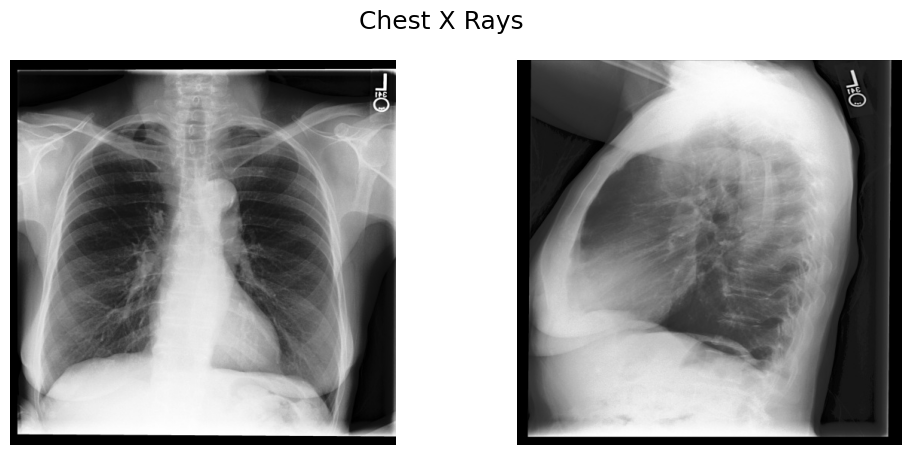

In [ ]:
# Read images
img1 = cv2.imread(img_path1)
img2 = cv2.imread(img_path2)
 

# Convert BGR -> RGB for correct colors
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
 

# Plot images side by side
plt.figure(figsize=(12,5))
plt.suptitle("Chest X Rays", fontsize=18)

plt.subplot(1,2,1)
plt.imshow(img1)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2)
plt.axis('off')

 

plt.show()

In [41]:
report = generate_single_report(
    model     = model,
    tokenizer = tokenizer,
    image_paths = [img_path1, img_path2],
    device = DEVICE,
)
# print(report)
import textwrap
wrapped_text = textwrap.fill(report, width=190)
print(wrapped_text)


Findings: Impression: In comparison with the study of _ _ _, there is little change and no evidence of acute cardiopulmonary disease. Cardiac silhouette is within normal limits and there is
no vascular congestion, pleural effusion, or acute focal pneumonia. Specifically, no hilar or mediastinal adenopathy. Results: Impressions: Compared to the _ _ study, there are hardly any
changes and no signs of an acute cardiovascular disease. Cardial Silhouettes are in normal limits, and there are no vascular stowages, pleural effusions or acute focus pneumonia. In
particular, no Hilar or Mediastinal Adenopathy. Especially no hilare or Mediastinum Adenopathy, especially no Hilare or mediastinal Adenopathy but no acute focus of


In [42]:
# Multiple questions on same X-ray study
for q in questions:
    answer_question(model, tokenizer,
      [img_path1, img_path2],
     q, DEVICE)
    print()


Q: Is there any pleural effusion?
A: PA and lateral chest views were obtained with patient in upright position. Analysis is performed in direct comparison with the next preceding similar study of _ _ _. The heart size is within normal limits. No typical configurational abnormality is identified. Thoracic aorta unremarkable. The pulmonary vasculature is not congested. No signs of acute or chronic parenchymal infiltrates are present and the lateral and posterior pleural sinuses are free. No pneumothorax in the apical area. Skeletal structures of the thorax grossly unremarkable. Impression: No evidence of

Q: Is the heart size normal?
A: The heart rate is normal? The medial and hilaric contours are normal.The lungs are clear, there is no pneumothorax or pleural effusion. There's no acute ossous anomalies. Impressions: No

Q: Is there pneumonia?
A: PA and lateral chest views were obtained with patient in upright position. Analysis is performed in direct comparison with the next preceding s